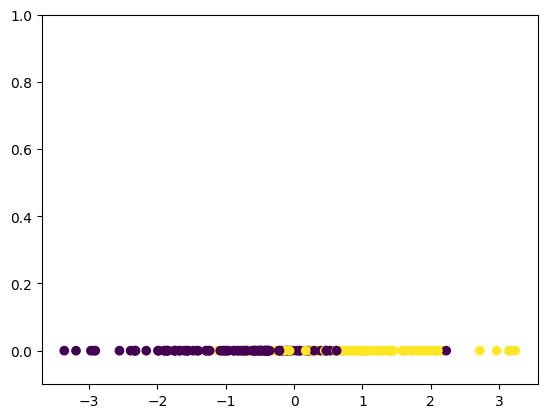

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

imbalance_factor = 0.75
n0 = 100
n1 = int(n0 * imbalance_factor)

X, y = make_blobs(n_samples=[n0, n1], centers=[[-1], [1]])

plt.scatter(X, np.zeros(X.shape[0]), c=y)
plt.ylim(-0.1, 1)
plt.show()

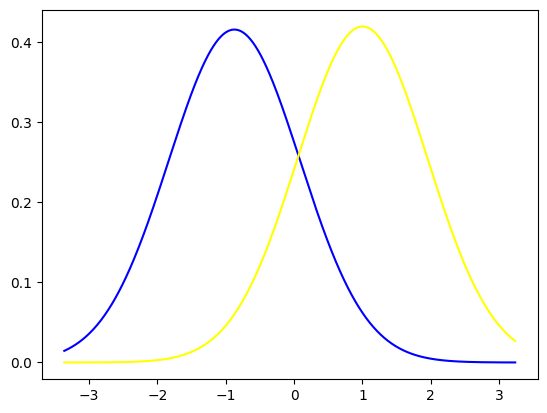

In [8]:
from scipy.stats import norm

x = np.linspace(np.min(X), np.max(X), 1000)

loc0, scale0 = np.mean(X[y == 0]), np.std(X[y == 0])
loc1, scale1 = np.mean(X[y == 1]), np.std(X[y == 1])

pdf0 = norm.pdf(x, loc=loc0, scale=scale0)
pdf1 = norm.pdf(x, loc=loc1, scale=scale1)

plt.plot(x, pdf0, c='blue')
plt.plot(x, pdf1, c='yellow')
plt.show()

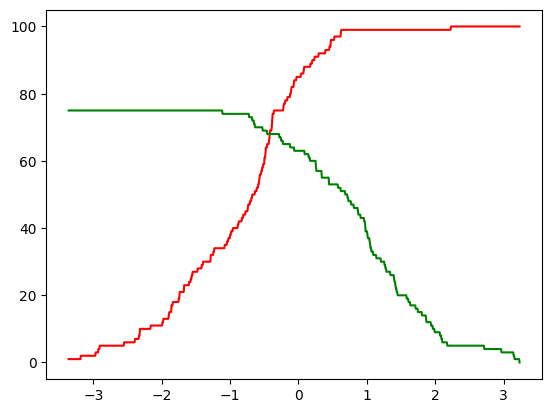

In [9]:
from sklearn.metrics import confusion_matrix

def pred(X, threshold):
  return np.where(X > threshold, 1, 0)

TN = []
TP = []

for threshold in x:
  y_pred = pred(X, threshold)
  tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
  TN.append(tn)
  TP.append(tp)

plt.plot(x, TN, c='red')
plt.plot(x, TP, c='green')
plt.show()

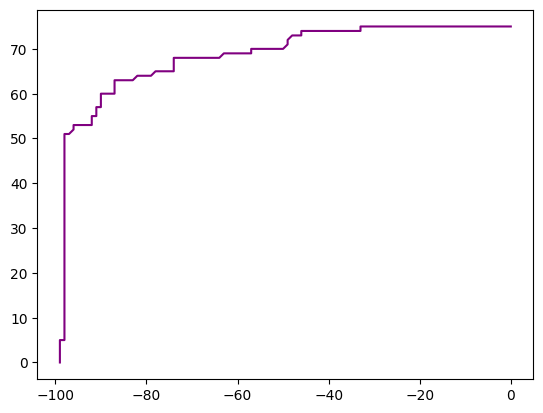

In [10]:
plt.plot(1 - np.array(TN), TP, c='purple')
plt.show()

In [11]:
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, roc_auc_score

def plot_cm_and_roc(gnb, X, y):
  gnb.fit(X, y)
  y_pred = gnb.predict(X)
  cm = confusion_matrix(y, y_pred)
  plt.figure()
  sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
  plt.xlabel("Predicted")
  plt.ylabel("Actual")
  plt.title("Confusion Matrix")
  plt.show()

  fpr, tpr, thresholds = roc_curve(y, gnb.predict_proba(X)[:, 1])
  plt.plot(fpr, tpr, label="ROC Curve")
  plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
  plt.show()

  auc = roc_auc_score(y, gnb.predict_proba(X)[:, 1])
  print(f"AUC: {auc:.2f}")

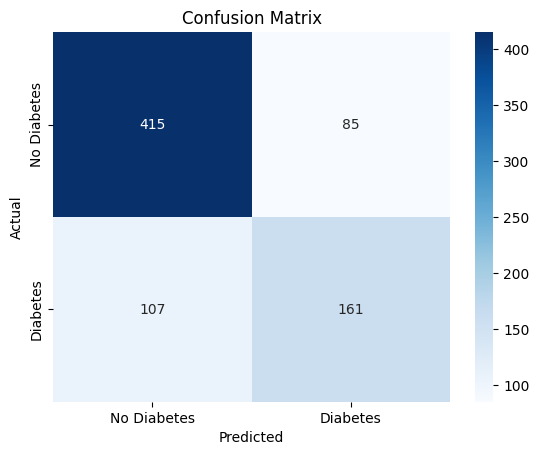

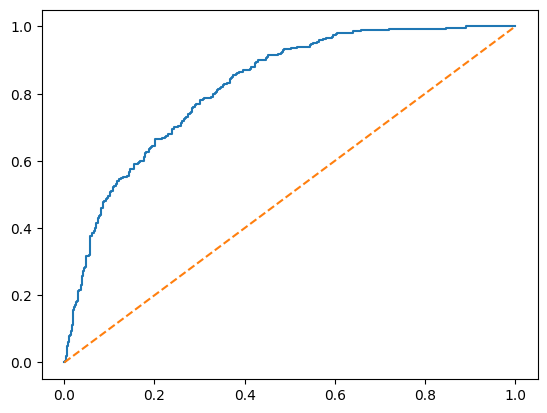

AUC: 0.82


In [12]:
import pandas as pd

def load_pima_diabetes():
  url = (
    "https://raw.githubusercontent.com/jbrownlee/Datasets/"
    "master/pima-indians-diabetes.data.csv"
  )
  cols = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
  ]
  df = pd.read_csv(url, header=None, names=cols)
  
  features = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
  
  for feat in features:
    df[feat] = df[feat].replace(0, np.nan)
    df[feat] = df[feat].fillna(df[feat].median())
  
  X = df.drop("Outcome", axis=1).values
  y = df["Outcome"].values
  return X, y



X, y = load_pima_diabetes()
gnb = GaussianNB()
plot_cm_and_roc(gnb, X, y)

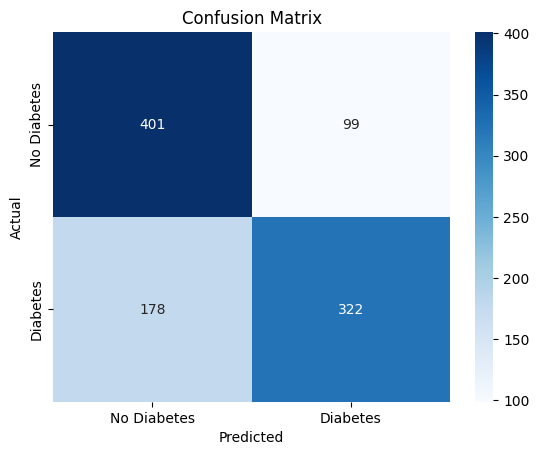

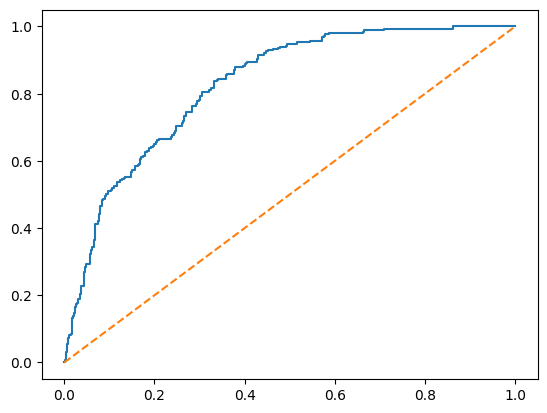

AUC: 0.83


In [13]:
from sklearn.utils import resample

unique, counts = np.unique(y, return_counts=True)
minority_y = unique[np.argmin(counts)]

X_minority = X[y == minority_y]
X_majority = X[y != minority_y]

X_minority_upsampled = resample(
  X_minority,
  replace=True,
  n_samples=len(X_majority)
)

X_upsampled = np.vstack((X_majority, X_minority_upsampled))
y_upsampled = np.hstack((y[y != minority_y], [minority_y] * len(X_majority)))

plot_cm_and_roc(gnb, X_upsampled, y_upsampled)

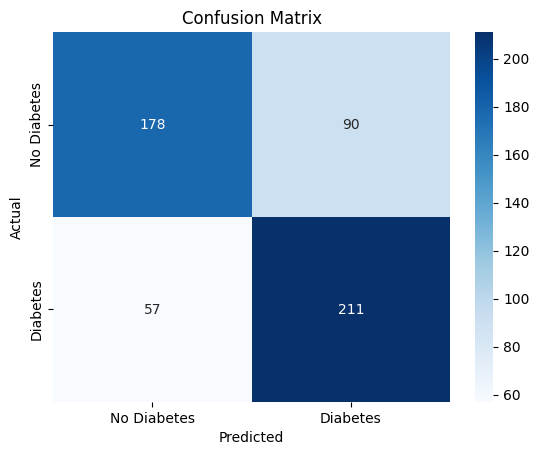

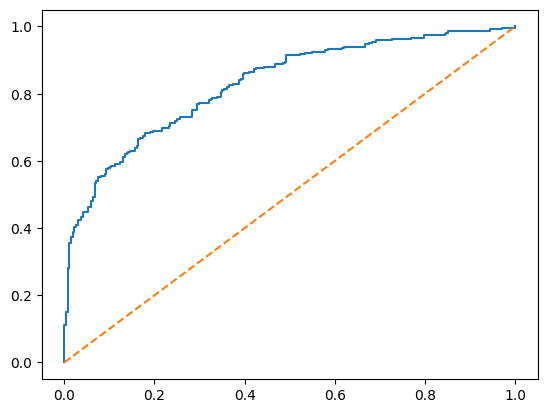

AUC: 0.83


In [17]:
X_majority_undersampled = resample(
  X_majority,
  replace=False,
  n_samples=len(X_minority)
)

X_undersampled = np.vstack((X_majority_undersampled, X_minority))
y_undersampled = np.hstack(([minority_y] * len(X_minority), y[y != minority_y][:len(X_minority)]))

plot_cm_and_roc(gnb, X_undersampled, y_undersampled)